In [100]:
import os
import numpy as np
import matplotlib.pyplot as plt

opj = os.path.join

basedir = '/ptmp/bing/2026_sbi_bmode'
tarpdir1 = opj(basedir, 'tarp90t_b')
tarpdir = opj(basedir, 'tarp89t_obsmat_g')

imgdir = '/ptmp/bing/2026_sbi_bmode/posterior_comparison_obsmat_only'
os.makedirs(imgdir, exist_ok=True)

In [101]:
# ============================================================
# Load TARP results: original
# ============================================================

alpha = np.load(opj(tarpdir, 'tarp_alpha.npy'))

ecp = np.load(opj(tarpdir, 'tarp_ecp.npy'))
ecp_boot = np.load(opj(tarpdir, 'tarp_ecp_boot.npy'))
ecp_std = np.std(ecp_boot, axis=0)

ecp_marg = np.load(opj(tarpdir, 'tarp_ecp_marg.npy'))
ecp_marg_boot = np.load(opj(tarpdir, 'tarp_ecp_marg_boot.npy'))
ecp_marg_std = np.std(ecp_marg_boot, axis=1)

# ============================================================
# Load TARP results: ObsMat
# ============================================================

alpha1 = np.load(opj(tarpdir1, 'tarp_alpha.npy'))

ecp1 = np.load(opj(tarpdir1, 'tarp_ecp.npy'))
ecp_boot1 = np.load(opj(tarpdir1, 'tarp_ecp_boot.npy'))
ecp_std1 = np.std(ecp_boot1, axis=0)

ecp_marg1 = np.load(opj(tarpdir1, 'tarp_ecp_marg.npy'))
ecp_marg_boot1 = np.load(opj(tarpdir1, 'tarp_ecp_marg_boot.npy'))
ecp_marg_std1 = np.std(ecp_marg_boot1, axis=1)

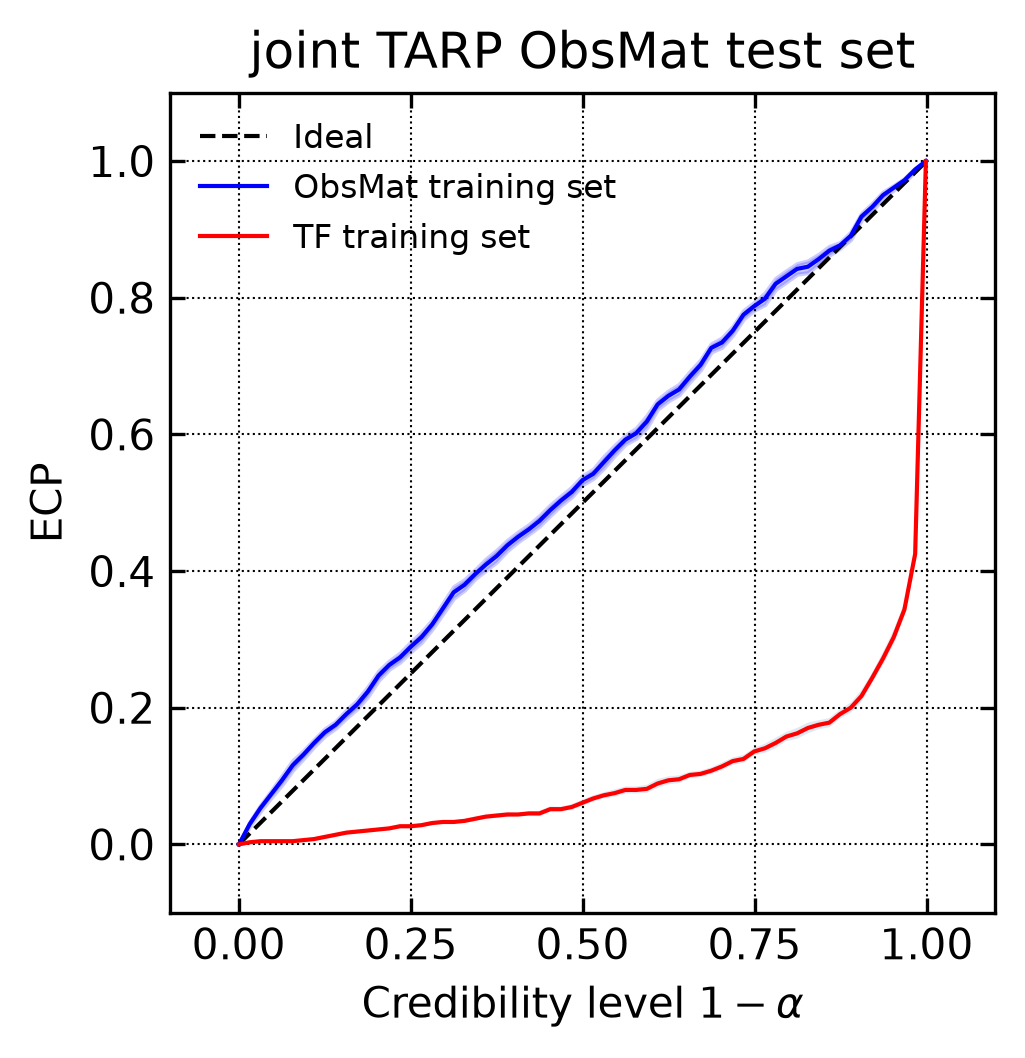

In [113]:

fig, ax = plt.subplots(figsize=(3.55, 3.55), dpi=300)

# Ideal calibration
ax.plot(
    alpha1, alpha1,
    'k--',
    lw=1,
    label='Ideal'
)

ax.plot(
    alpha1, ecp1,
    lw=1,
    linestyle='-',
    label='ObsMat training set',
    color="blue"
)

ax.fill_between(
    alpha1,
    ecp1 - 2 * ecp_std1,
    ecp1 + 2 * ecp_std1,
    alpha=0.2,
    color="blue"
)


ax.plot(
    alpha1, ecp,
    lw=1,
    # linestyle=':',
    color="red",
    label='TF training set'
)

ax.fill_between(
    alpha1,
    ecp - 2 * ecp_std,
    ecp + 2 * ecp_std,
    alpha=0.15
)

ax.set_xlim(-0.1, 1.1)
ax.set_ylim(-0.1, 1.1)

ax.set_xlabel(r'Credibility level $1-\alpha$')
ax.set_ylabel(r'$\mathrm{ECP}$')

ax.tick_params(
    'both',
    which='both',
    direction='in',
    right=True,
    top=True
)

ax.grid(
    color='black',
    linestyle='dotted',
    linewidth=0.5
)

ax.legend(
    frameon=False,
    # loc='upper left',
    fontsize=8
)

ax.set_title("joint TARP ObsMat test set")

fig.savefig(
    opj(imgdir, 'tarp_joint_compare_obsmat.png'),
    bbox_inches='tight'
)

plt.show()

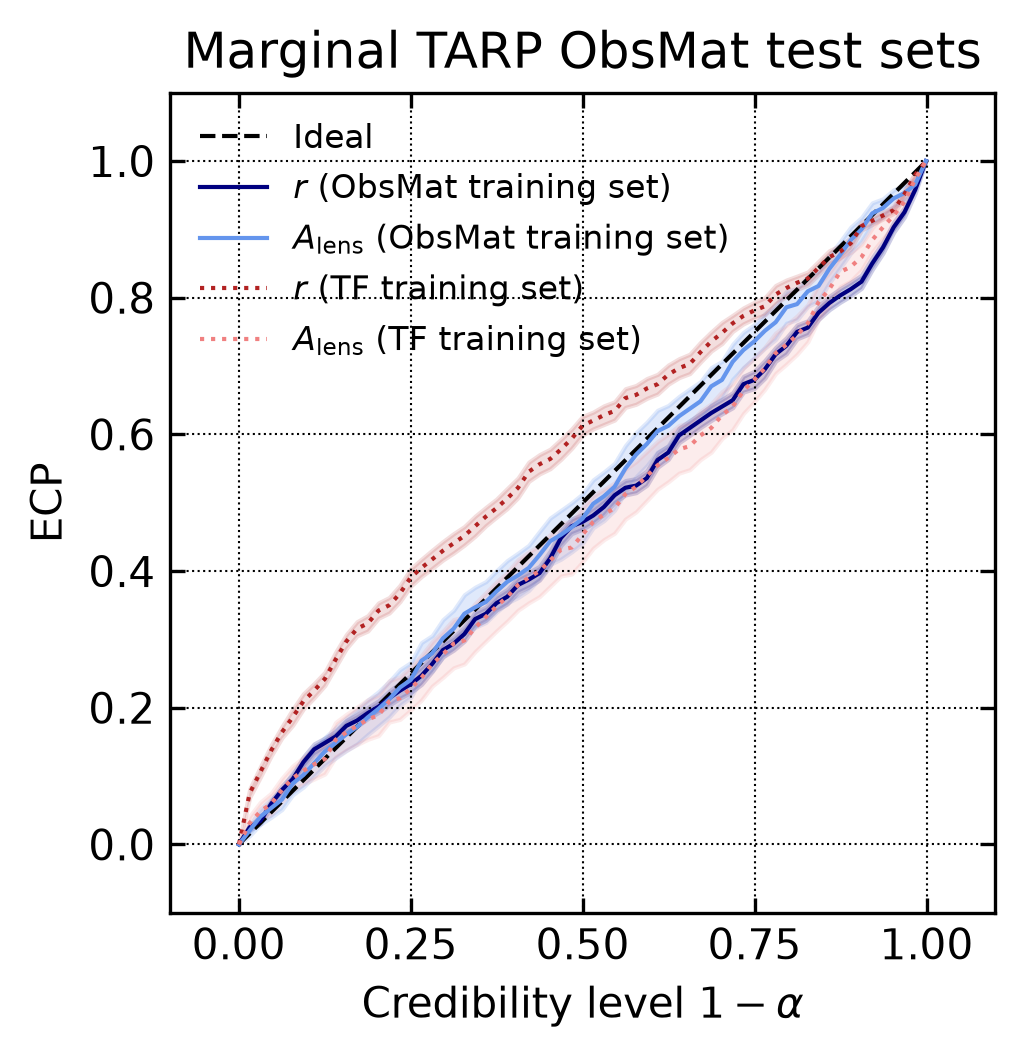

In [109]:
fig, ax = plt.subplots(figsize=(3.55, 3.55), dpi=300)

# Match colors to the triangle plot: ObsMat -> red, TF -> blue.
# Use two shades per family to still distinguish r vs A_lens.
COLORS_TF = {0: 'firebrick', 1: 'lightcoral'}
COLORS_OBSMAT = {0: 'navy', 1: 'cornflowerblue'}

ax.plot(
    alpha1, alpha1,
    'k--',
    lw=1,
    label='Ideal'
)

for pidx, param in zip([0, 1], [r'$r$', r'$A_{\mathrm{lens}}$']):

    ax.plot(
        alpha1,
        ecp_marg1[pidx],
        lw=1,
        linestyle='-',
        color=COLORS_OBSMAT[pidx],
        label=param + ' (ObsMat training set)'
    )

    ax.fill_between(
        alpha1,
        ecp_marg1[pidx] - 2 * ecp_marg_std1[pidx],
        ecp_marg1[pidx] + 2 * ecp_marg_std1[pidx],
        alpha=0.2,
        color=COLORS_OBSMAT[pidx],
    )


# ============================================================
# ObsMat TARP
# ==========================================================

for pidx, param in zip([0, 1], [r'$r$', r'$A_{\mathrm{lens}}$']):

    ax.plot(
        alpha1,
        ecp_marg[pidx],
        lw=1,
        linestyle=':',
        color=COLORS_TF[pidx],
        label=param + ' (TF training set)'
    )

    ax.fill_between(
        alpha1,
        ecp_marg[pidx] - 2 * ecp_marg_std[pidx],
        ecp_marg[pidx] + 2 * ecp_marg_std[pidx],
        alpha=0.15,
        color=COLORS_TF[pidx],
    )

ax.set_xlim(-0.1, 1.1)
ax.set_ylim(-0.1, 1.1)

ax.set_xlabel(r'Credibility level $1-\alpha$')
ax.set_ylabel(r'$\mathrm{ECP}$')

ax.tick_params(
    'both',
    which='both',
    direction='in',
    right=True,
    top=True
)

ax.grid(
    color='black',
    linestyle='dotted',
    linewidth=0.5
)

ax.legend(
    frameon=False,
    loc='upper left',
    fontsize=8
)

ax.set_title("Marginal TARP ObsMat test sets")

fig.savefig(
    opj(imgdir, 'tarp_marginal_compare_obsmat.png'),
    bbox_inches='tight'
)

plt.show()

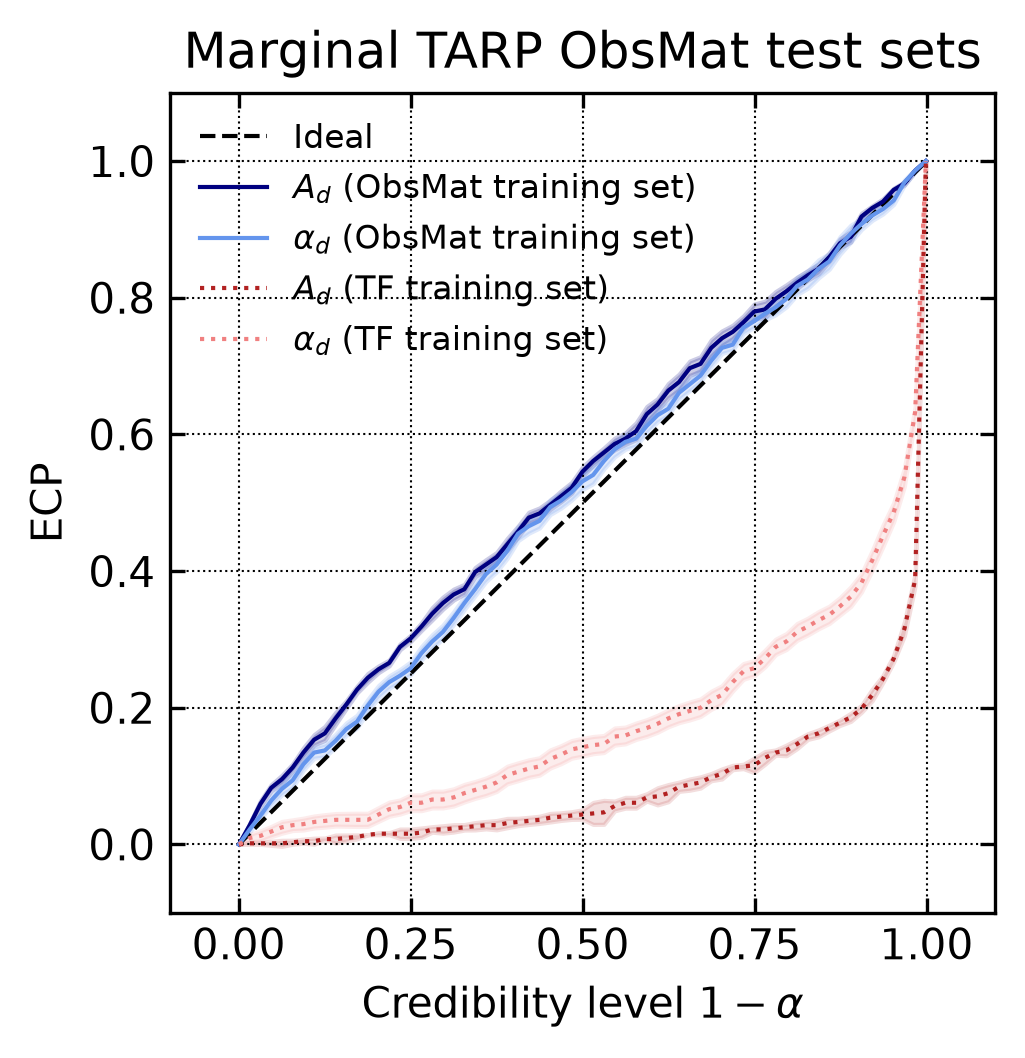

In [112]:
fig, ax = plt.subplots(figsize=(3.55, 3.55), dpi=300)

# Match colors to the triangle plot: ObsMat -> red, TF -> blue.
# Use two shades per family to still distinguish r vs A_lens.
COLORS_TF = {2: 'firebrick', 3: 'lightcoral'}
COLORS_OBSMAT = {2: 'navy', 3: 'cornflowerblue'}

ax.plot(
    alpha1, alpha1,
    'k--',
    lw=1,
    label='Ideal'
)

for pidx, param in zip([2, 3], [r'$A_d$', r'$\alpha_d$']):

    ax.plot(
        alpha1,
        ecp_marg1[pidx],
        lw=1,
        linestyle='-',
        color=COLORS_OBSMAT[pidx],
        label=param + ' (ObsMat training set)'
    )

    ax.fill_between(
        alpha1,
        ecp_marg1[pidx] - 2 * ecp_marg_std1[pidx],
        ecp_marg1[pidx] + 2 * ecp_marg_std1[pidx],
        alpha=0.2,
        color=COLORS_OBSMAT[pidx],
    )


# ============================================================
# ObsMat TARP
# ==========================================================

for pidx, param in zip([2, 3], [r'$A_d$', r'$\alpha_d$']):
    ax.plot(
        alpha1,
        ecp_marg[pidx],
        lw=1,
        linestyle=':',
        color=COLORS_TF[pidx],
        label=param + ' (TF training set)'
    )

    ax.fill_between(
        alpha1,
        ecp_marg[pidx] - 2 * ecp_marg_std[pidx],
        ecp_marg[pidx] + 2 * ecp_marg_std[pidx],
        alpha=0.15,
        color=COLORS_TF[pidx],
    )

ax.set_xlim(-0.1, 1.1)
ax.set_ylim(-0.1, 1.1)

ax.set_xlabel(r'Credibility level $1-\alpha$')
ax.set_ylabel(r'$\mathrm{ECP}$')

ax.tick_params(
    'both',
    which='both',
    direction='in',
    right=True,
    top=True
)

ax.grid(
    color='black',
    linestyle='dotted',
    linewidth=0.5
)

ax.legend(
    frameon=False,
    # loc='upper left',
    fontsize=8
)

ax.set_title("Marginal TARP ObsMat test sets")

fig.savefig(
    opj(imgdir, 'tarp_marginal_compare_obsmat_dust.png'),
    bbox_inches='tight'
)

plt.show()

In [48]:
basedir = '/ptmp/bing/2026_sbi_bmode'

tarpdir = opj(basedir, 'tarp89t_obsmat_g')   # Transfer function, N = 20480, test on ObsMat
tarpdir1 = opj(basedir, 'tarp90t_b')         # ObsMat-only, N = 20480, test on ObsMat
tarpdir2 = opj(basedir, 'tarp91hf_a')        # Multifidelity: N_TF = 20480, N_ObsMat = 2048, test on ObsMat

imgdir = '/ptmp/bing/2026_sbi_bmode/posterior_comparison'
os.makedirs(imgdir, exist_ok=True)


In [40]:
# ============================================================
# Load TARP results: Transfer Function
# ============================================================

alpha = np.load(opj(tarpdir, 'tarp_alpha.npy'))

ecp = np.load(opj(tarpdir, 'tarp_ecp.npy'))
ecp_boot = np.load(opj(tarpdir, 'tarp_ecp_boot.npy'))
ecp_std = np.std(ecp_boot, axis=0)

ecp_marg = np.load(opj(tarpdir, 'tarp_ecp_marg.npy'))
ecp_marg_boot = np.load(opj(tarpdir, 'tarp_ecp_marg_boot.npy'))
ecp_marg_std = np.std(ecp_marg_boot, axis=1)


# ============================================================
# Load TARP results: ObsMat-only
# ============================================================

alpha1 = np.load(opj(tarpdir1, 'tarp_alpha.npy'))

ecp1 = np.load(opj(tarpdir1, 'tarp_ecp.npy'))
ecp_boot1 = np.load(opj(tarpdir1, 'tarp_ecp_boot.npy'))
ecp_std1 = np.std(ecp_boot1, axis=0)

ecp_marg1 = np.load(opj(tarpdir1, 'tarp_ecp_marg.npy'))
ecp_marg_boot1 = np.load(opj(tarpdir1, 'tarp_ecp_marg_boot.npy'))
ecp_marg_std1 = np.std(ecp_marg_boot1, axis=1)


# ============================================================
# Load TARP results: Multifidelity
# ============================================================

alpha2 = np.load(opj(tarpdir2, 'tarp_alpha.npy'))

ecp2 = np.load(opj(tarpdir2, 'tarp_ecp.npy'))
ecp_boot2 = np.load(opj(tarpdir2, 'tarp_ecp_boot.npy'))
ecp_std2 = np.std(ecp_boot2, axis=0)

ecp_marg2 = np.load(opj(tarpdir2, 'tarp_ecp_marg.npy'))
ecp_marg_boot2 = np.load(opj(tarpdir2, 'tarp_ecp_marg_boot.npy'))
ecp_marg_std2 = np.std(ecp_marg_boot2, axis=1)

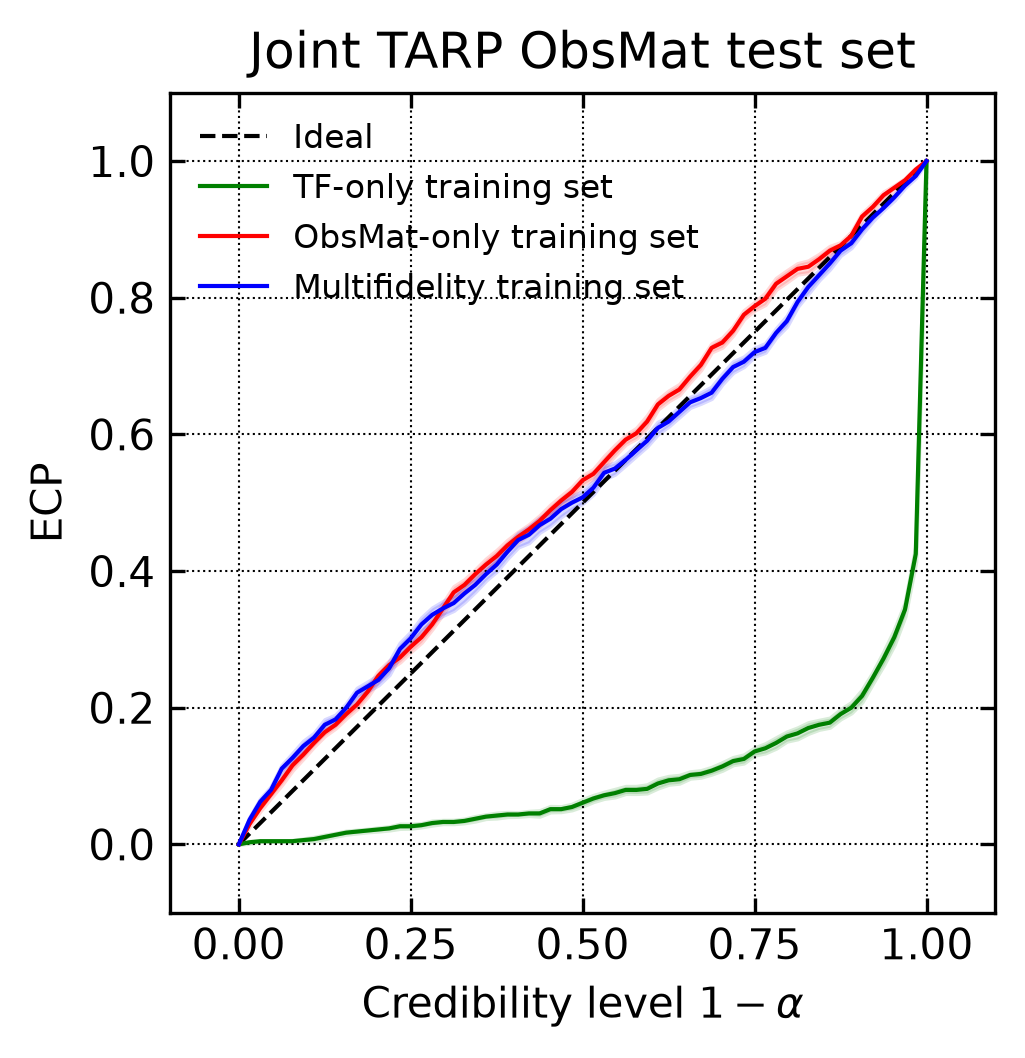

In [42]:
fig, ax = plt.subplots(figsize=(3.55, 3.55), dpi=300)

# Ideal calibration
ax.plot(
    alpha2,
    alpha2,
    'k--',
    lw=1,
    label='Ideal'
)

# Transfer function
ax.plot(
    alpha2,
    ecp,
    lw=1,
    linestyle='-',
    color='green',
    label='TF-only training set'
)

ax.fill_between(
    alpha2,
    ecp - 2 * ecp_std,
    ecp + 2 * ecp_std,
    alpha=0.15,
    color='green'
)

# ObsMat-only
ax.plot(
    alpha2,
    ecp1,
    lw=1,
    linestyle='-',
    color='red',
    label='ObsMat-only training set'
)

ax.fill_between(
    alpha2,
    ecp1 - 2 * ecp_std1,
    ecp1 + 2 * ecp_std1,
    alpha=0.15,
    color='red'
)

# Multifidelity
ax.plot(
    alpha2,
    ecp2,
    lw=1,
    linestyle='-',
    color='blue',
    label='Multifidelity training set'
)

ax.fill_between(
    alpha2,
    ecp2 - 2 * ecp_std2,
    ecp2 + 2 * ecp_std2,
    alpha=0.15,
    color='blue'
)

ax.set_xlim(-0.1, 1.1)
ax.set_ylim(-0.1, 1.1)

ax.set_xlabel(r'Credibility level $1-\alpha$')
ax.set_ylabel(r'$\mathrm{ECP}$')

ax.tick_params(
    'both',
    which='both',
    direction='in',
    right=True,
    top=True
)

ax.grid(
    color='black',
    linestyle='dotted',
    linewidth=0.5
)

ax.legend(
    frameon=False,
    fontsize=8
)

ax.set_title("Joint TARP ObsMat test set")

fig.savefig(
    opj(imgdir, 'tarp_joint_compare_obsmat_test_set.png'),
    bbox_inches='tight'
)

plt.show()

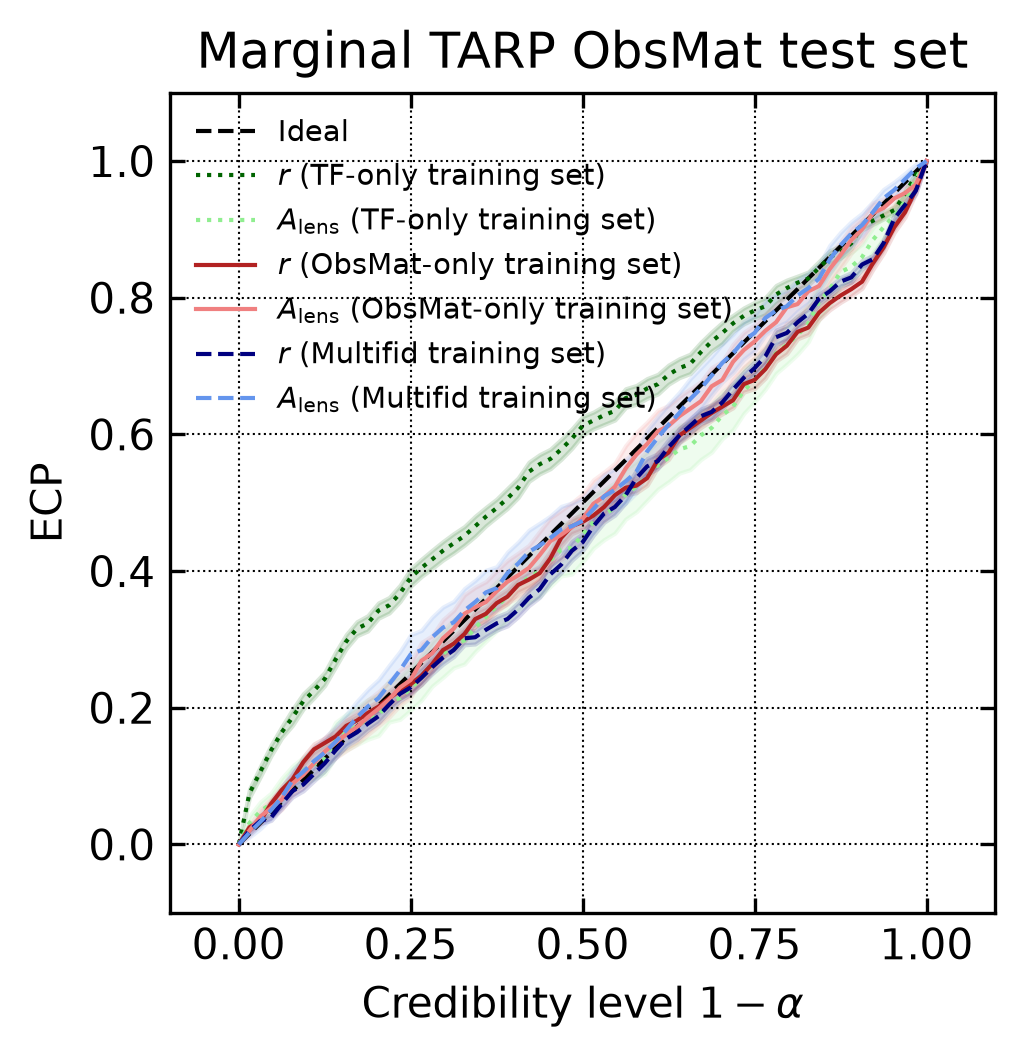

In [49]:
fig, ax = plt.subplots(figsize=(3.55, 3.55), dpi=300)

# ============================================================
# Colors
# ============================================================

COLORS_TF = {0: 'darkgreen', 1: 'lightgreen'}
COLORS_OBSMAT = {0: 'firebrick', 1: 'lightcoral'}
COLORS_MULTIFID = {0: 'navy', 1: 'cornflowerblue'}


# ============================================================
# Ideal calibration
# ============================================================

ax.plot(
    alpha2,
    alpha2,
    'k--',
    lw=1,
    label='Ideal'
)


# ============================================================
# TF-only
# ============================================================

for pidx, param in zip([0, 1], [r'$r$', r'$A_{\mathrm{lens}}$']):

    ax.plot(
        alpha2,
        ecp_marg[pidx],
        lw=1,
        linestyle=':',
        color=COLORS_TF[pidx],
        label=param + ' (TF-only training set)'
    )

    ax.fill_between(
        alpha2,
        ecp_marg[pidx] - 2 * ecp_marg_std[pidx],
        ecp_marg[pidx] + 2 * ecp_marg_std[pidx],
        alpha=0.15,
        color=COLORS_TF[pidx],
    )


# ============================================================
# ObsMat-only
# ============================================================

for pidx, param in zip([0, 1], [r'$r$', r'$A_{\mathrm{lens}}$']):

    ax.plot(
        alpha2,
        ecp_marg1[pidx],
        lw=1,
        linestyle='-',
        color=COLORS_OBSMAT[pidx],
        label=param + ' (ObsMat-only training set)'
    )

    ax.fill_between(
        alpha2,
        ecp_marg1[pidx] - 2 * ecp_marg_std1[pidx],
        ecp_marg1[pidx] + 2 * ecp_marg_std1[pidx],
        alpha=0.15,
        color=COLORS_OBSMAT[pidx],
    )


# ============================================================
# Multifidelity
# ============================================================

for pidx, param in zip([0, 1], [r'$r$', r'$A_{\mathrm{lens}}$']):

    ax.plot(
        alpha2,
        ecp_marg2[pidx],
        lw=1,
        linestyle='--',
        color=COLORS_MULTIFID[pidx],
        label=param + ' (Multifid training set)'
    )

    ax.fill_between(
        alpha2,
        ecp_marg2[pidx] - 2 * ecp_marg_std2[pidx],
        ecp_marg2[pidx] + 2 * ecp_marg_std2[pidx],
        alpha=0.15,
        color=COLORS_MULTIFID[pidx],
    )


# ============================================================
# Formatting
# ============================================================

ax.set_xlim(-0.1, 1.1)
ax.set_ylim(-0.1, 1.1)

ax.set_xlabel(r'Credibility level $1-\alpha$')
ax.set_ylabel(r'$\mathrm{ECP}$')

ax.tick_params(
    'both',
    which='both',
    direction='in',
    right=True,
    top=True
)

ax.grid(
    color='black',
    linestyle='dotted',
    linewidth=0.5
)

ax.legend(
    frameon=False,
    # loc='upper left',
    fontsize=7
)

ax.set_title("Marginal TARP ObsMat test set")

fig.savefig(
    opj(imgdir, 'tarp_marginal_compare_obsmat_test_set.png'),
    bbox_inches='tight'
)

plt.show()

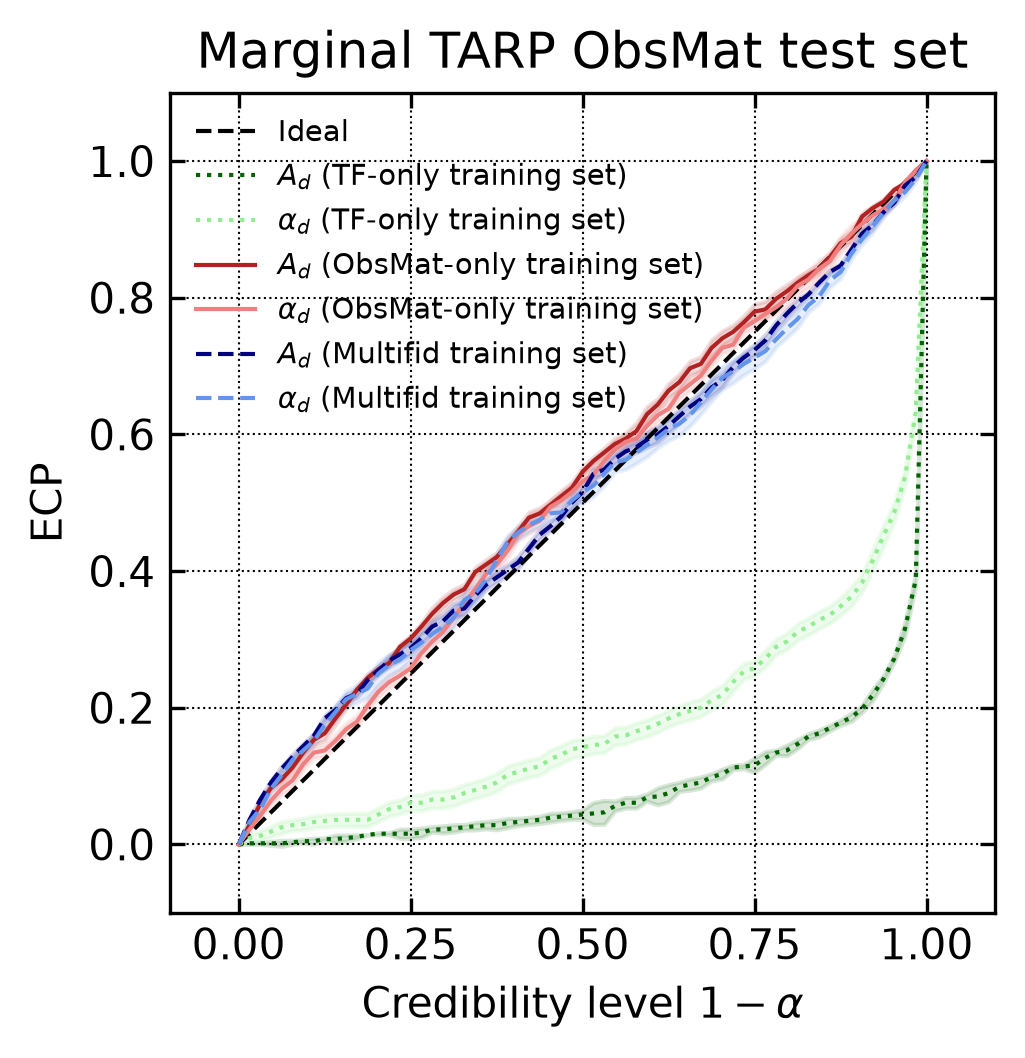

In [50]:
fig, ax = plt.subplots(figsize=(3.55, 3.55), dpi=300)

# ============================================================
# Colors
# ============================================================

COLORS_TF = {2: 'darkgreen', 3: 'lightgreen'}
COLORS_OBSMAT = {2: 'firebrick', 3: 'lightcoral'}
COLORS_MULTIFID = {2: 'navy', 3: 'cornflowerblue'}


# ============================================================
# Ideal calibration
# ============================================================

ax.plot(
    alpha2,
    alpha2,
    'k--',
    lw=1,
    label='Ideal'
)


# ============================================================
# TF-only
# ============================================================

for pidx, param in zip([2, 3], [r'$A_d$', r'$\alpha_d$']):

    ax.plot(
        alpha2,
        ecp_marg[pidx],
        lw=1,
        linestyle=':',
        color=COLORS_TF[pidx],
        label=param + ' (TF-only training set)'
    )

    ax.fill_between(
        alpha2,
        ecp_marg[pidx] - 2 * ecp_marg_std[pidx],
        ecp_marg[pidx] + 2 * ecp_marg_std[pidx],
        alpha=0.15,
        color=COLORS_TF[pidx],
    )


# ============================================================
# ObsMat-only
# ============================================================

for pidx, param in zip([2, 3], [r'$A_d$', r'$\alpha_d$']):

    ax.plot(
        alpha2,
        ecp_marg1[pidx],
        lw=1,
        linestyle='-',
        color=COLORS_OBSMAT[pidx],
        label=param + ' (ObsMat-only training set)'
    )

    ax.fill_between(
        alpha2,
        ecp_marg1[pidx] - 2 * ecp_marg_std1[pidx],
        ecp_marg1[pidx] + 2 * ecp_marg_std1[pidx],
        alpha=0.15,
        color=COLORS_OBSMAT[pidx],
    )


# ============================================================
# Multifidelity
# ============================================================

for pidx, param in zip([2, 3], [r'$A_d$', r'$\alpha_d$']):

    ax.plot(
        alpha2,
        ecp_marg2[pidx],
        lw=1,
        linestyle='--',
        color=COLORS_MULTIFID[pidx],
        label=param + ' (Multifid training set)'
    )

    ax.fill_between(
        alpha2,
        ecp_marg2[pidx] - 2 * ecp_marg_std2[pidx],
        ecp_marg2[pidx] + 2 * ecp_marg_std2[pidx],
        alpha=0.15,
        color=COLORS_MULTIFID[pidx],
    )


# ============================================================
# Formatting
# ============================================================

ax.set_xlim(-0.1, 1.1)
ax.set_ylim(-0.1, 1.1)

ax.set_xlabel(r'Credibility level $1-\alpha$')
ax.set_ylabel(r'$\mathrm{ECP}$')

ax.tick_params(
    'both',
    which='both',
    direction='in',
    right=True,
    top=True
)

ax.grid(
    color='black',
    linestyle='dotted',
    linewidth=0.5
)

ax.legend(
    frameon=False,
    fontsize=7
)

ax.set_title("Marginal TARP ObsMat test set")

fig.savefig(
    opj(imgdir, 'tarp_marginal_compare_obsmat_dust_test_set.png'),
    bbox_inches='tight'
)

plt.show()

N_HF =    128    loss = -7.86581069e+00
N_HF =    384    loss = -7.94802700e+00
N_HF =    768    loss = -8.01862365e+00
N_HF =   1152    loss = -8.12655271e+00
N_HF =   1536    loss = -8.31349638e+00
N_HF =   2048    loss = -8.25401939e+00
N_HF =   4096    loss = -8.46659946e+00
N_HF =  20480    loss = -8.33480537e+00


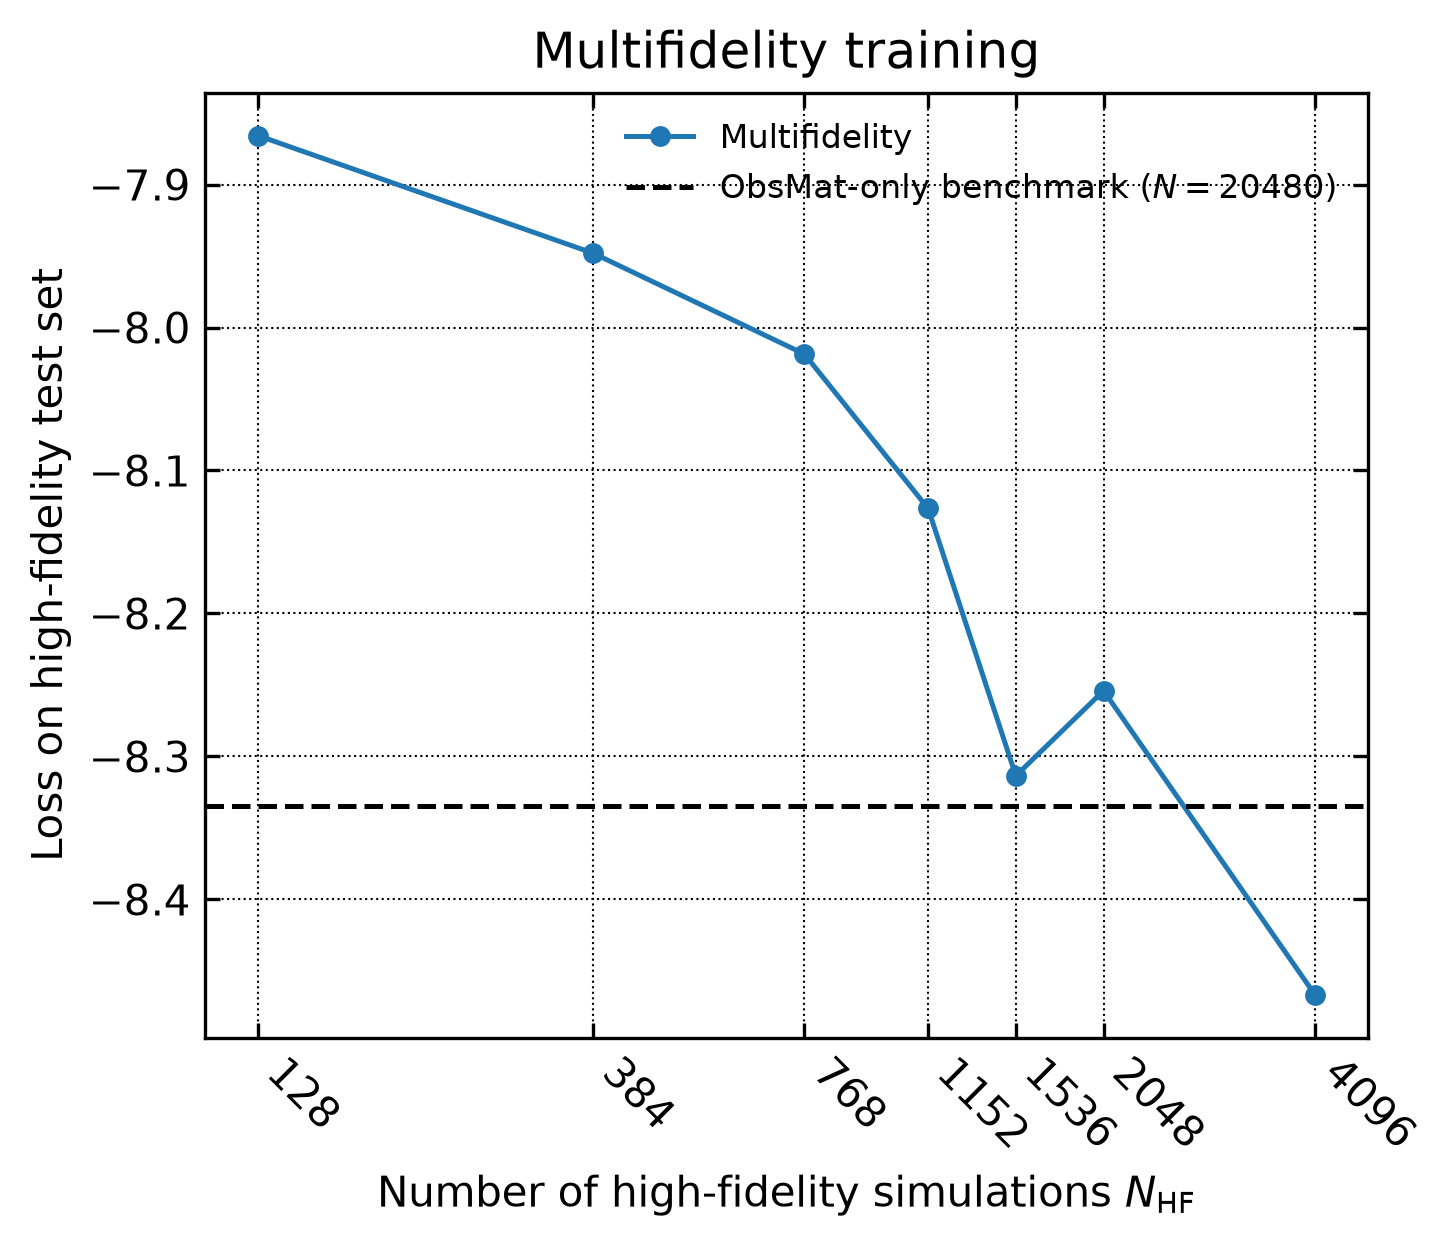

In [65]:
import os
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# Extract first loss from results.txt
# ============================================================
def extract_first_loss(optdir):
    results_file = os.path.join(
        optdir,
        "img",
        "results.txt",
    )

    if not os.path.isfile(results_file):
        raise FileNotFoundError(
            f"Could not find:\n{results_file}"
        )

    with open(results_file, "r") as f:
        for line in f:
            line = line.strip()

            if not line:
                continue

            if line.startswith("#"):
                continue

            values = line.split()

            if len(values) < 2:
                continue

            return float(values[1])

    raise ValueError(
        f"No data rows found in:\n{results_file}"
    )


# ============================================================
# Optuna directories
# ============================================================
optdirs = [
    "/ptmp/bing/2026_sbi_bmode/run91hf_optuna_c",   # 128
    "/ptmp/bing/2026_sbi_bmode/run91hf_optuna_d",   # 384
    "/ptmp/bing/2026_sbi_bmode/run91hf_optuna_e",   # 768
    "/ptmp/bing/2026_sbi_bmode/run91hf_optuna_f",   # 1152
    "/ptmp/bing/2026_sbi_bmode/run91hf_optuna_g",   # 1536
    "/ptmp/bing/2026_sbi_bmode/run91hf_optuna_a",   # 2048
    "/ptmp/bing/2026_sbi_bmode/run91hf_optuna_b",   # 4096
    "/ptmp/bing/2026_sbi_bmode/run90_optuna_b",     # 20480 ObsMat-only
]


# ============================================================
# Number of high-fidelity simulations
# ============================================================
nsims = np.array([
    128,
    384,
    768,
    1152,
    1536,
    2048,
    4096,
    20480,
])


# ============================================================
# Extract losses
# ============================================================
losses = np.array([
    extract_first_loss(optdir)
    for optdir in optdirs
])


# Print results
for nsim, loss in zip(nsims, losses):
    print(
        f"N_HF = {nsim:>6}    loss = {loss:.8e}"
    )


# ============================================================
# Separate multifidelity and ObsMat-only benchmark
# ============================================================
nsims_mf = nsims[:-1]
losses_mf = losses[:-1]

nsim_benchmark = nsims[-1]
loss_benchmark = losses[-1]


# ============================================================
# Plot
# ============================================================
fig, ax = plt.subplots(
    figsize=(5, 5),
    dpi=300,
)


# ------------------------------------------------------------
# Multifidelity
# ------------------------------------------------------------
ax.plot(
    nsims_mf,
    losses_mf,
    marker="o",
    linestyle="-",
    lw=1.2,
    ms=4,
    label="Multifidelity",
)


# ------------------------------------------------------------
# ObsMat-only benchmark
# ------------------------------------------------------------
ax.axhline(
    loss_benchmark,
    color="black",
    linestyle="--",
    lw=1.2,
    label=r"ObsMat-only benchmark ($N=20480$)",
)


# ------------------------------------------------------------
# Labels
# ------------------------------------------------------------
ax.set_xlabel(
    r"Number of high-fidelity simulations $N_{\rm HF}$"
)

ax.set_ylabel(
    "Loss on high-fidelity test set"
)

ax.set_title(
    "Multifidelity training"
)


# ------------------------------------------------------------
# Log x-axis
# ------------------------------------------------------------
ax.set_xscale("log")

ax.set_xticks(nsims_mf)

ax.set_xticklabels(
    [str(n) for n in nsims_mf],
    rotation=-45,
    ha="left",
)

ax.minorticks_off()
# ------------------------------------------------------------
# Tick style
# ------------------------------------------------------------
ax.tick_params(
    "both",
    which="both",
    direction="in",
    right=True,
    top=True,
)


# ------------------------------------------------------------
# Grid
# ------------------------------------------------------------
ax.grid(
    color="black",
    linestyle="dotted",
    linewidth=0.5,
)


# ------------------------------------------------------------
# Legend
# ------------------------------------------------------------
ax.legend(
    frameon=False,
    fontsize=8,
)


# ------------------------------------------------------------
# Layout
# ------------------------------------------------------------
plt.subplots_adjust(
    bottom=0.25,
)

plt.show()

In [89]:
# ============================================================
# Load TARP results
# ============================================================

def load_tarp(tarpdir):
    """Load TARP results from a directory."""

    alpha = np.load(os.path.join(tarpdir, "tarp_alpha.npy"))
    ecp = np.load(os.path.join(tarpdir, "tarp_ecp.npy"))
    ecp_boot = np.load(os.path.join(tarpdir, "tarp_ecp_boot.npy"))

    ecp_std = np.std(ecp_boot, axis=0)

    ecp_marg = np.load(
        os.path.join(tarpdir, "tarp_ecp_marg.npy")
    )

    ecp_marg_boot = np.load(
        os.path.join(tarpdir, "tarp_ecp_marg_boot.npy")
    )

    ecp_marg_std = np.std(
        ecp_marg_boot,
        axis=1
    )

    return {
        "alpha": alpha,
        "ecp": ecp,
        "ecp_std": ecp_std,
        "ecp_marg": ecp_marg,
        "ecp_marg_std": ecp_marg_std,
    }


# ============================================================
# Format axis
# ============================================================

def format_axis(ax, title):

    ax.set_xlim(-0.1, 1.1)
    ax.set_ylim(-0.1, 1.1)

    ax.set_xlabel(r"Credibility level $1-\alpha$")
    ax.set_ylabel(r"$\mathrm{ECP}$")

    ax.set_title(title)

    ax.tick_params(
        axis="both",
        which="both",
        direction="in",
        top=True,
        right=True,
    )

    ax.grid(
        True,
        linestyle=":",
        linewidth=0.7,
        color="black",
        alpha=0.5,
    )


# ============================================================
# Plot TARP
# ============================================================

def plot_tarp(
    tarpdirs,
    labels,
    mode="joint",
    title="TARP",
    figsize=(3.55, 3.55),
    dpi=300,
    show=True,
):

    if len(tarpdirs) != len(labels):
        raise ValueError(
            "The number of TARP directories must match "
            "the number of labels."
        )

    # --------------------------------------------------------
    # Load results
    # --------------------------------------------------------

    results = []

    for tarpdir in tarpdirs:

        if not os.path.isdir(tarpdir):
            raise FileNotFoundError(
                f"TARP directory does not exist:\n{tarpdir}"
            )

        print(f"Loading: {tarpdir}")
        results.append(load_tarp(tarpdir))

    # --------------------------------------------------------
    # Colors
    # --------------------------------------------------------

    nresults = len(results)

    if nresults <= 5:

        cmap = plt.get_cmap("tab10")
        colors = [
            cmap(i)
            for i in range(nresults)
        ]

    else:

        cmap = plt.get_cmap("viridis")
        colors = [
            cmap(i / max(nresults - 1, 1))
            for i in range(nresults)
        ]

    # ========================================================
    # JOINT TARP
    # ========================================================

    if mode == "joint":

        fig, ax = plt.subplots(
            figsize=figsize,
            dpi=dpi,
        )

        # ----------------------------------------------------
        # Ideal calibration
        # ----------------------------------------------------

        alpha = results[2]["alpha"]

        ax.plot(
            alpha,
            alpha,
            color="black",
            linestyle="--",
            linewidth=1.0,
            label="Ideal",
        )

        # ----------------------------------------------------
        # Plot each result
        # ----------------------------------------------------

        for i, result in enumerate(results):

            ecp = result["ecp"]
            ecp_std = result["ecp_std"]

            ax.plot(
                alpha,
                ecp,
                color=colors[i],
                linewidth=1.2,
                label=labels[i],
            )

            ax.fill_between(
                alpha,
                ecp - 2.0 * ecp_std,
                ecp + 2.0 * ecp_std,
                color=colors[i],
                alpha=0.08,
            )

        # ----------------------------------------------------
        # Formatting
        # ----------------------------------------------------

        format_axis(ax, title)

        ax.legend(
            loc="upper left",
            fontsize=6,
            frameon=False,
        )

        fig.tight_layout()

        if show:
            plt.show()

        return fig, ax

    # ========================================================
    # MARGINAL TARP
    # ========================================================

    elif mode == "marginal":

        parameters = [
            (0, r"$r$", "r"),
            (1, r"$A_{\mathrm{lens}}$", "Alens"),
        ]

        figures = {}

        for pidx, parameter_name, parameter_tag in parameters:

            fig, ax = plt.subplots(
                figsize=figsize,
                dpi=dpi,
            )

            # ------------------------------------------------
            # Ideal calibration
            # ------------------------------------------------

            alpha = results[1]["alpha"]

            ax.plot(
                alpha,
                alpha,
                color="black",
                linestyle="--",
                linewidth=1.0,
                label="Ideal",
            )

            # ------------------------------------------------
            # Plot each result
            # ------------------------------------------------

            for i, result in enumerate(results):

                ecp_marg = result["ecp_marg"][pidx]
                ecp_marg_std = result["ecp_marg_std"][pidx]

                ax.plot(
                    alpha,
                    ecp_marg,
                    color=colors[i],
                    linewidth=1.2,
                    label=labels[i],
                )

                ax.fill_between(
                    alpha,
                    ecp_marg - 2.0 * ecp_marg_std,
                    ecp_marg + 2.0 * ecp_marg_std,
                    color=colors[i],
                    alpha=0.08,
                )

            # ------------------------------------------------
            # Formatting
            # ------------------------------------------------

            format_axis(
                ax,
                f"{title}: {parameter_name}",
            )

            ax.legend(
                loc="upper left",
                fontsize=7,
                frameon=False,
            )

            fig.tight_layout()

            figures[parameter_tag] = (fig, ax)

            if show:
                plt.show()

        return figures

In [92]:
# ============================================================
# Plot marginal TARP
# ============================================================

def plot_tarp_marginal(
    tarpdirs,
    labels,
    title="Marginal TARP",
    figsize=(3.55, 3.55),
    dpi=300,
    show=True,
):

    if len(tarpdirs) != len(labels):
        raise ValueError(
            "The number of TARP directories must match "
            "the number of labels."
        )

    # --------------------------------------------------------
    # Load results
    # --------------------------------------------------------

    results = []

    for tarpdir in tarpdirs:

        if not os.path.isdir(tarpdir):
            raise FileNotFoundError(
                f"TARP directory does not exist:\n{tarpdir}"
            )

        print(f"Loading: {tarpdir}")

        results.append(load_tarp(tarpdir))


    # --------------------------------------------------------
    # Parameter definitions
    # --------------------------------------------------------

    parameters = [
        (0, r"$r$", "r"),
        (1, r"$A_{\mathrm{lens}}$", "Alens"),
        (2, r"$A_d$", "Ad"),
        (3, r"$\alpha_d$", "alphad"),
    ]


    # --------------------------------------------------------
    # Colors
    # --------------------------------------------------------

    # TF-only
    color_tf = "darkgreen"

    # ObsMat-only
    color_obsmat = "firebrick"

    # Multifidelity
    color_multifid = "navy"

    # Different MultiFid N values
    n_multifid = 7

    cmap_multifid = plt.get_cmap("Blues")

    multifid_colors = [
        cmap_multifid(
            0.45 + 0.45 * i / max(n_multifid - 1, 1)
        )
        for i in range(n_multifid)
    ]


    # --------------------------------------------------------
    # Line styles
    # --------------------------------------------------------

    # TF-only
    linestyle_tf = ":"

    # ObsMat-only
    linestyle_obsmat = "-"

    # MultiFid
    linestyle_multifid = "--"


    # --------------------------------------------------------
    # Identify result indices
    # --------------------------------------------------------

    # Your ordering is:
    #
    # 0 = TF-only
    # 1 = MultiFid 128
    # 2 = MultiFid 384
    # 3 = MultiFid 768
    # 4 = MultiFid 1152
    # 5 = MultiFid 1536
    # 6 = MultiFid 2048
    # 7 = MultiFid 4096
    # 8 = ObsMat-only

    tf_idx = 0

    multifid_indices = [
        1, 2, 3, 4, 5, 6, 7
    ]

    obsmat_idx = 8


    # --------------------------------------------------------
    # Create one figure per parameter
    # --------------------------------------------------------

    figures = {}


    for pidx, parameter_name, parameter_tag in parameters:

        fig, ax = plt.subplots(
            figsize=figsize,
            dpi=dpi,
        )


        # ====================================================
        # Ideal calibration
        # ====================================================

        alpha = results[1]["alpha"]

        ax.plot(
            alpha,
            alpha,
            color="black",
            linestyle="--",
            linewidth=1.0,
            label="Ideal",
        )


        # ====================================================
        # TF-only
        # ====================================================

        result = results[tf_idx]

        ecp_marg = result["ecp_marg"][pidx]

        ecp_marg_std = result["ecp_marg_std"][pidx]

        ax.plot(
            alpha,
            ecp_marg,
            linewidth=1.2,
            linestyle=linestyle_tf,
            color=color_tf,
            label="TF-only",
        )

        ax.fill_between(
            alpha,
            ecp_marg - 2.0 * ecp_marg_std,
            ecp_marg + 2.0 * ecp_marg_std,
            color=color_tf,
            alpha=0.08,
        )


        # ====================================================
        # MultiFid
        # ====================================================

        for j, result_idx in enumerate(multifid_indices):

            result = results[result_idx]

            ecp_marg = result["ecp_marg"][pidx]

            ecp_marg_std = result["ecp_marg_std"][pidx]

            ax.plot(
                alpha,
                ecp_marg,
                linewidth=1.1,
                linestyle=linestyle_multifid,
                color=multifid_colors[j],
                label=labels[result_idx],
            )

            ax.fill_between(
                alpha,
                ecp_marg - 2.0 * ecp_marg_std,
                ecp_marg + 2.0 * ecp_marg_std,
                color=multifid_colors[j],
                alpha=0.06,
            )


        # ====================================================
        # ObsMat-only
        # ====================================================

        result = results[obsmat_idx]

        ecp_marg = result["ecp_marg"][pidx]

        ecp_marg_std = result["ecp_marg_std"][pidx]

        ax.plot(
            alpha,
            ecp_marg,
            linewidth=1.2,
            linestyle=linestyle_obsmat,
            color=color_obsmat,
            label="ObsMat-only",
        )

        ax.fill_between(
            alpha,
            ecp_marg - 2.0 * ecp_marg_std,
            ecp_marg + 2.0 * ecp_marg_std,
            color=color_obsmat,
            alpha=0.08,
        )


        # ====================================================
        # Formatting
        # ====================================================

        format_axis(
            ax,
            f"{title}: {parameter_name}",
        )

        ax.legend(
            loc="upper left",
            fontsize=6,
            frameon=False,
        )

        fig.tight_layout()

        figures[parameter_tag] = (fig, ax)

        if show:
            plt.show()


    return figures

In [87]:
base = "/ptmp/bing/2026_sbi_bmode"

tarp_obs_obs = f"{base}/tarp90t_b"
tarp_tf_obs = f"{base}/tarp89t_obsmat_g"

tarp_128  = f"{base}/tarp91hf_c"
tarp_384  = f"{base}/tarp91hf_d"
tarp_768  = f"{base}/tarp91hf_e"
tarp_1152 = f"{base}/tarp91hf_f"
tarp_1536 = f"{base}/tarp91hf_g"
tarp_2048 = f"{base}/tarp91hf_a"
tarp_4096 = f"{base}/tarp91hf_b"

tarpdirs = [
    tarp_tf_obs,
    tarp_128,
    tarp_384,
    tarp_768,
    tarp_1152,
    tarp_1536,
    tarp_2048,
    tarp_4096,
    tarp_obs_obs,
]

labels = [
    "Train: Transfer $N=20480$",
    "MultiFid $N_{obsmat}=128$",
    "MultiFid $N_{obsmat}=384$",
    "MultiFid $N_{obsmat}=768$",
    "MultiFid $N_{obsmat}=1152$",
    "MultiFid $N_{obsmat}=1536$",
    "MultiFid $N_{obsmat}=2048$",
    "MultiFid $N_{obsmat}=4096$",
    "Train: ObsMat $N=20480$",
]

Loading: /ptmp/bing/2026_sbi_bmode/tarp89t_obsmat_g
Loading: /ptmp/bing/2026_sbi_bmode/tarp91hf_c
Loading: /ptmp/bing/2026_sbi_bmode/tarp91hf_d
Loading: /ptmp/bing/2026_sbi_bmode/tarp91hf_e
Loading: /ptmp/bing/2026_sbi_bmode/tarp91hf_f
Loading: /ptmp/bing/2026_sbi_bmode/tarp91hf_g
Loading: /ptmp/bing/2026_sbi_bmode/tarp91hf_a
Loading: /ptmp/bing/2026_sbi_bmode/tarp91hf_b
Loading: /ptmp/bing/2026_sbi_bmode/tarp90t_b


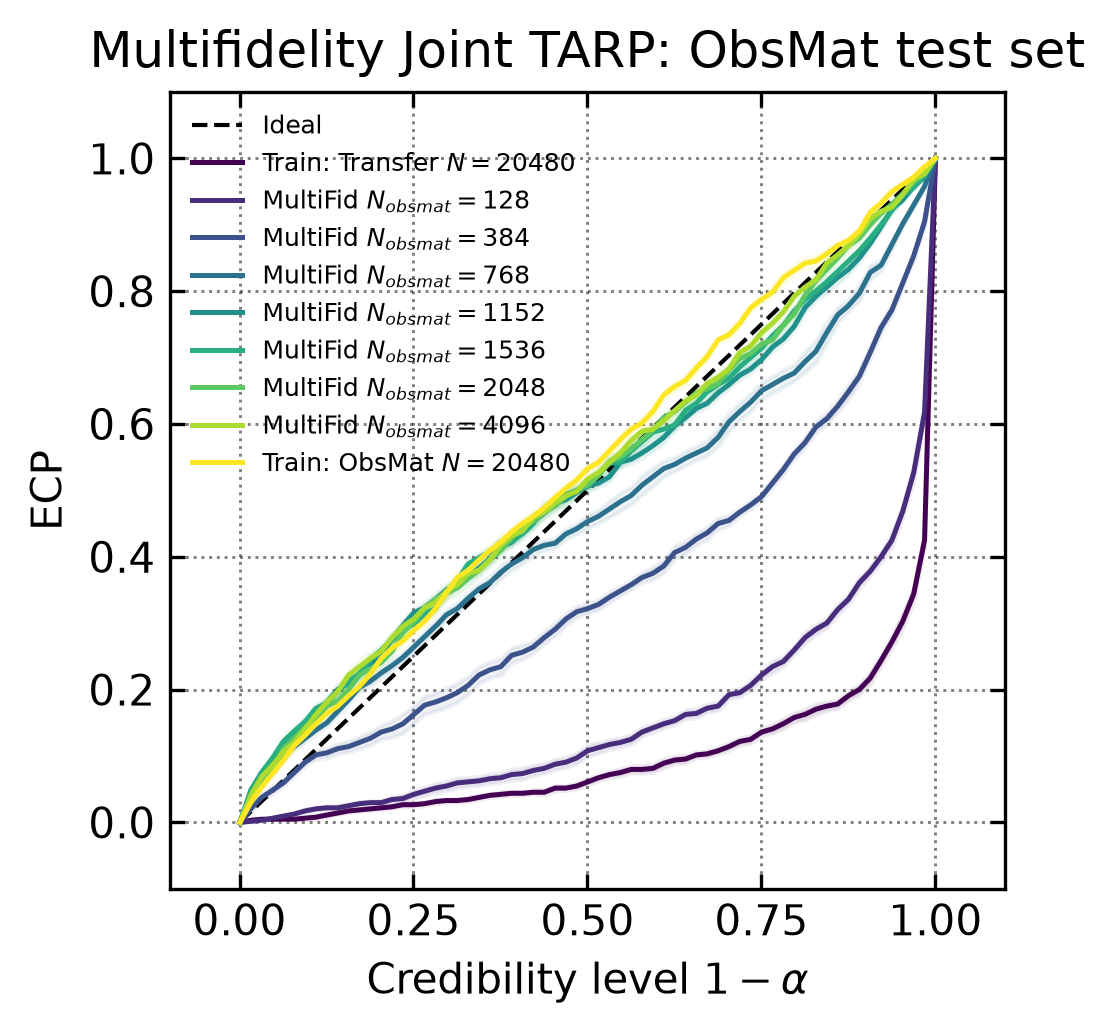

In [93]:
fig, ax = plot_tarp(
    tarpdirs=tarpdirs,
    labels=labels,
    mode="joint",
    title="Multifidelity Joint TARP: ObsMat test set",
)

Loading: /ptmp/bing/2026_sbi_bmode/tarp89t_obsmat_g
Loading: /ptmp/bing/2026_sbi_bmode/tarp91hf_c
Loading: /ptmp/bing/2026_sbi_bmode/tarp91hf_d
Loading: /ptmp/bing/2026_sbi_bmode/tarp91hf_e
Loading: /ptmp/bing/2026_sbi_bmode/tarp91hf_f
Loading: /ptmp/bing/2026_sbi_bmode/tarp91hf_g
Loading: /ptmp/bing/2026_sbi_bmode/tarp91hf_a
Loading: /ptmp/bing/2026_sbi_bmode/tarp91hf_b
Loading: /ptmp/bing/2026_sbi_bmode/tarp90t_b


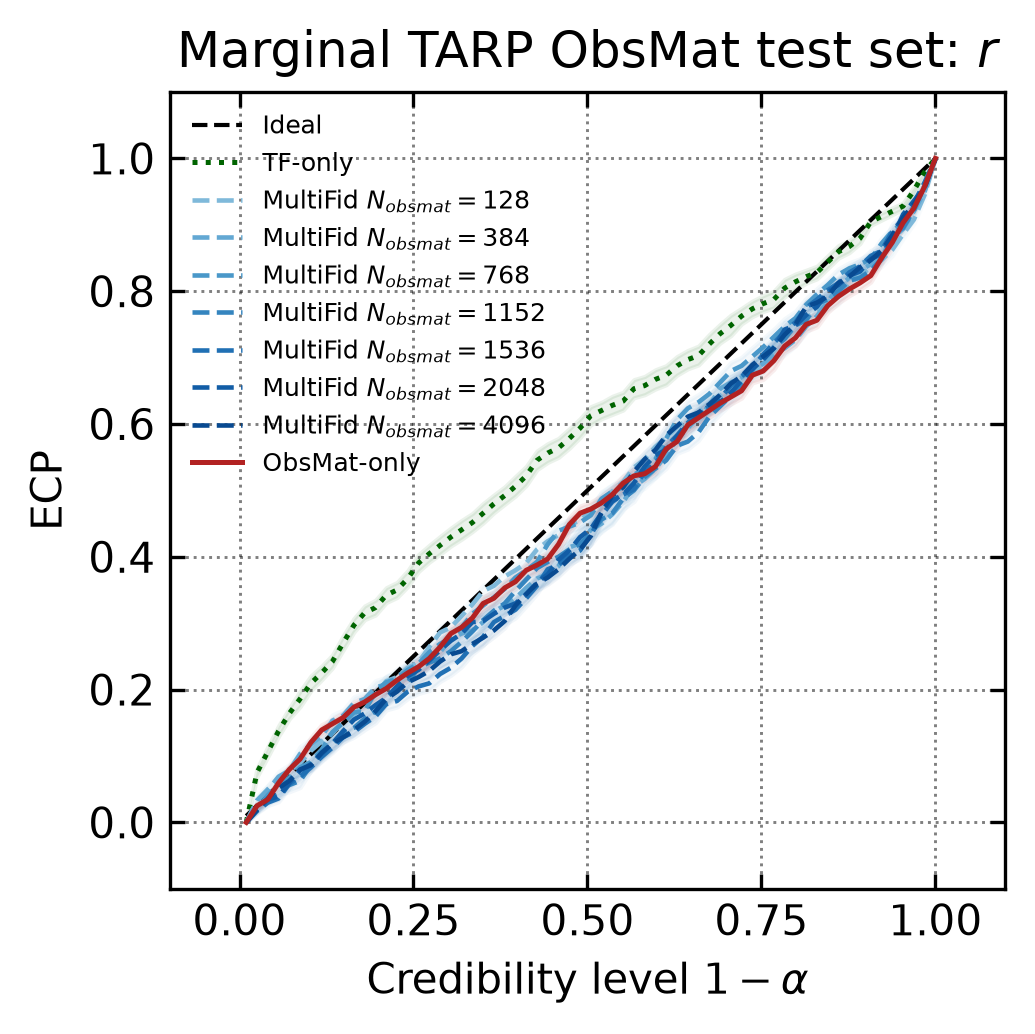

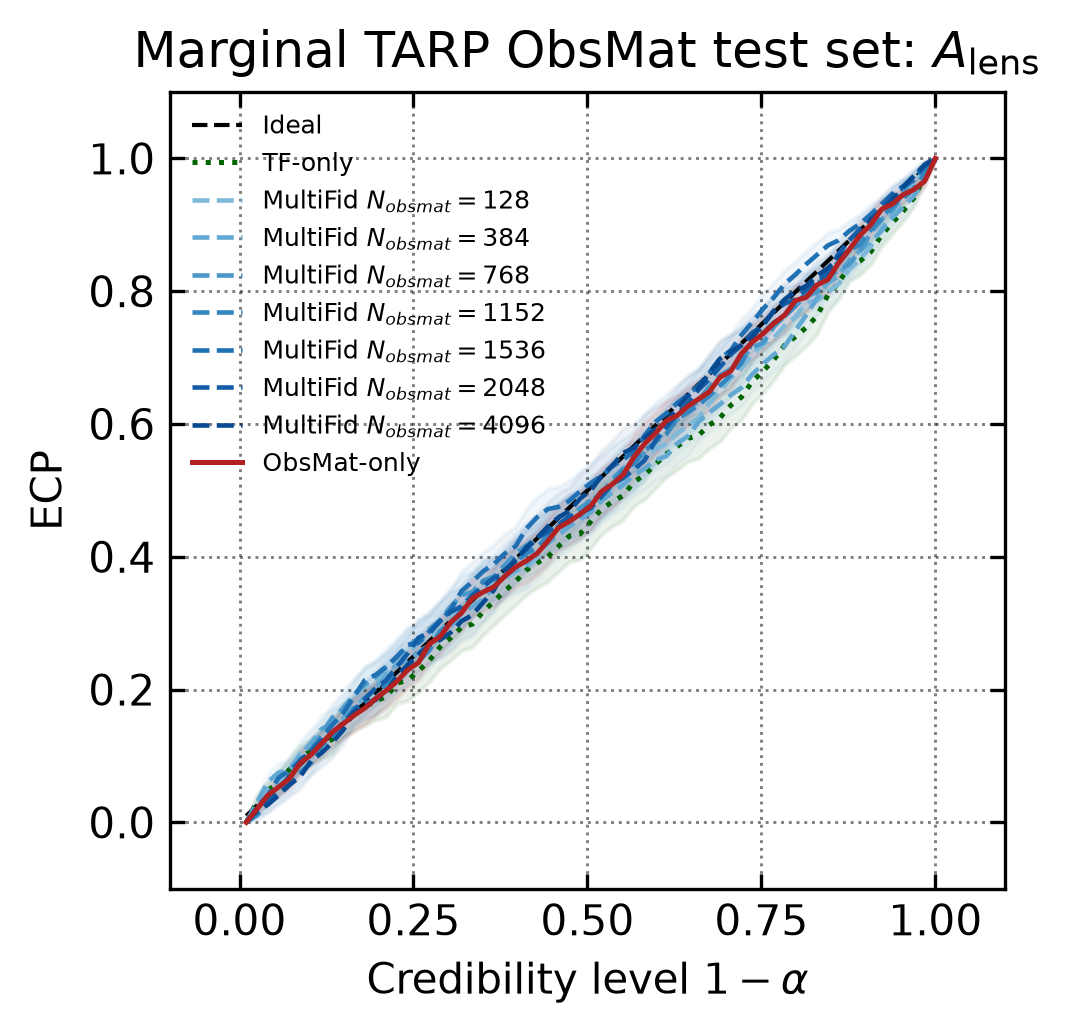

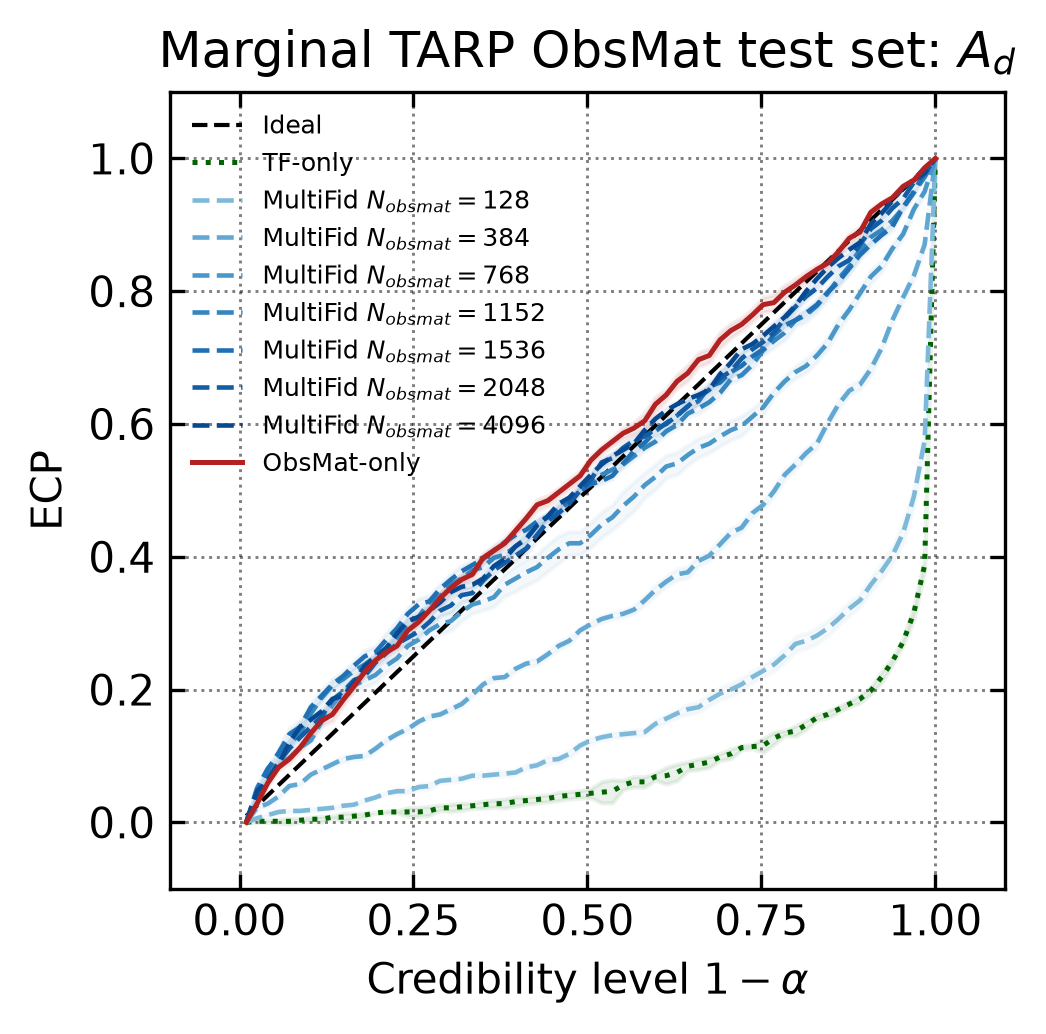

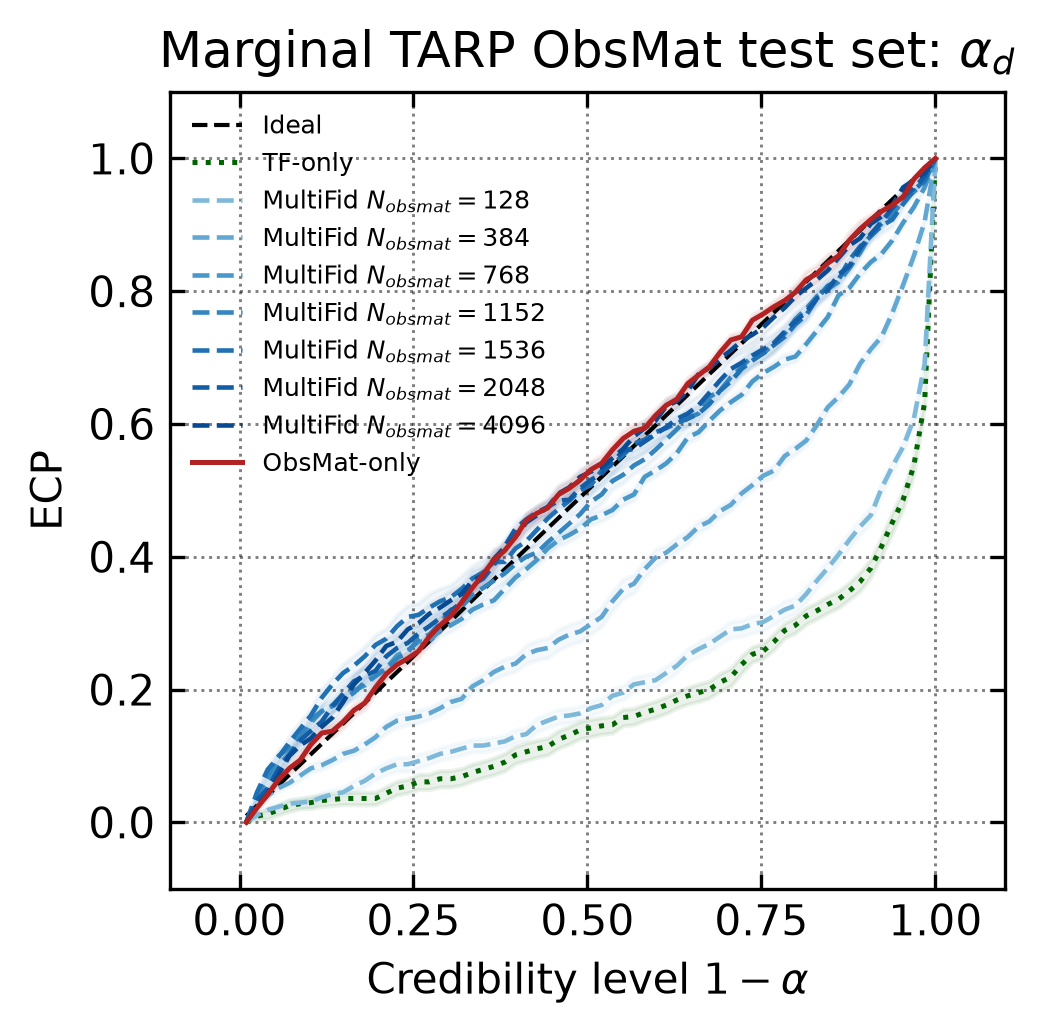

In [96]:
figures = plot_tarp_marginal(
    tarpdirs=tarpdirs,
    labels=labels,
    title="Marginal TARP ObsMat test set",
)